   Feature1  Feature2 Target
0    1.7250       520    Yes
1    1.8875       428     No
2    1.6000       552    Yes
3    1.4250       500     No
4    1.7750       628     No
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1020 non-null   float64
 1   Feature2  1020 non-null   int64  
 2   Target    1000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 24.0+ KB
None
           Feature1     Feature2
count   1020.000000  1020.000000
mean      11.436679   520.988235
std      313.061049    69.793442
min        1.250000   400.000000
25%        1.450000   464.000000
50%        1.637500   520.000000
75%        1.828125   584.000000
max    10000.000000   640.000000
Target
No     784
Yes    215
Name: count, dtype: int64


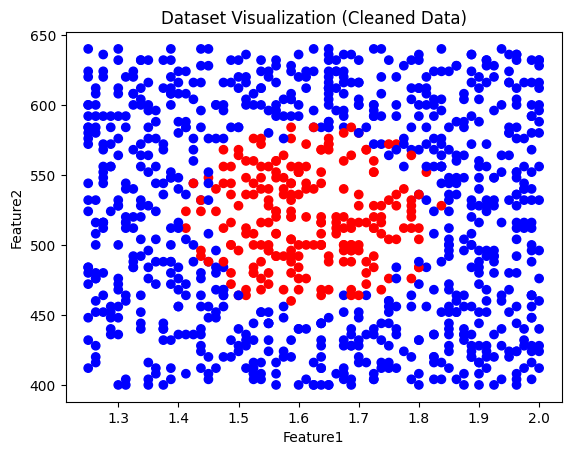

Accuracy: 0.555

Confusion Matrix
[[87 71]
 [18 24]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.55      0.66       158
           1       0.25      0.57      0.35        42

    accuracy                           0.56       200
   macro avg       0.54      0.56      0.51       200
weighted avg       0.71      0.56      0.60       200



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


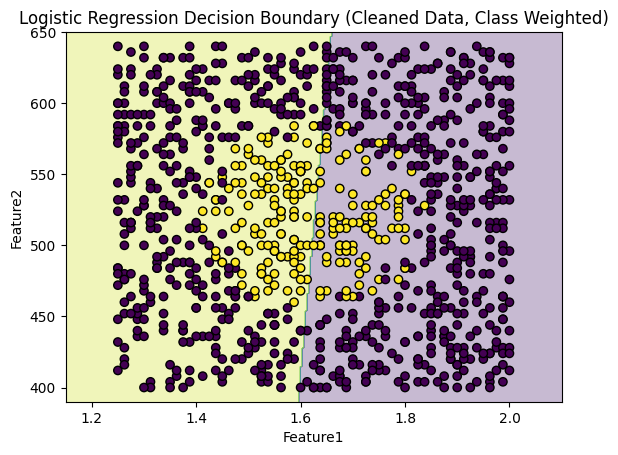

In [18]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("/Lab_Exam_binary_classification_dataset.csv")


print(df.head())
print(df.info())
print(df.describe())

df_cleaned = df.dropna(subset=['Target'])

values > 100 are outliers.
df_cleaned = df_cleaned[df_cleaned['Feature1'] < 100]

print(df_cleaned['Target'].value_counts())

colors = df_cleaned['Target'].map({'Yes':'red','No':'blue'})

plt.scatter(df_cleaned['Feature1'], df_cleaned['Feature2'], c=colors)
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Dataset Visualization (Cleaned Data)")
plt.show()

X = df_cleaned[['Feature1','Feature2']]
y = df_cleaned['Target']

encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



print("Accuracy:", accuracy_score(y_test,y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))

print("\nClassification Report")
print(classification_report(y_test,y_pred))


x_min, x_max = X['Feature1'].min()-0.1, X['Feature1'].max()+0.1
y_min, y_max = X['Feature2'].min()-10, X['Feature2'].max()+10

xx, yy = np.meshgrid(
    np.linspace(x_min,x_max,300),
    np.linspace(y_min,y_max,300)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx,yy,Z,alpha=0.3)

plt.scatter(X['Feature1'],X['Feature2'],c=y,edgecolors='k')

plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Logistic Regression Decision Boundary (Cleaned Data, Class Weighted)")

plt.show()